# Vectorless RAG: Multi-Hop Claims Adjudication & Benefit Tables

This notebook demonstrates two advanced use cases where Vectorless RAG outperforms standard chunking-based RAG:

1. **Multi-Hop Claims Adjudication** — fetching discrete variables (dates, deductibles, limits) from different parts of a policy without introducing noise.
2. **Benefit Tables & Rate Charts** — retrieving whole logical nodes that preserve table structure, headers, and footnotes.

Standard Vector RAG often fails here because:
- Chunking shatters tables and cross-references.
- Embedding similarity retrieves irrelevant nearby text.
- Multi-hop reasoning requires fetching multiple distant nodes, which chunking mixes together.

## 1. Prerequisites

This notebook assumes you have:

- A complex insurance policy PDF in a local `data/` folder.
- A PageIndex API key for tree generation.
- A Groq API key for the free LLM endpoint.

The LLM layer uses [Groq](https://groq.com/) via its OpenAI-compatible endpoint. You can choose between `llama-3.3-70b-versatile` (larger) and `llama-3.1-8b-instant` (faster) at runtime.

### API Key Setup

You will need two API keys:

| Key | Where to get it |
|-----|------------------|
| `GROQ_API_KEY` | [https://console.groq.com/keys](https://console.groq.com/keys) |
| `PAGEINDEX_API_KEY` | [https://www.pageindex.ai](https://www.pageindex.ai) |

Set them as environment variables or in a `.env` file in the same directory as this notebook:

```
GROQ_API_KEY=gsk_...
PAGEINDEX_API_KEY=...
```

In [12]:
%pip install -q --upgrade pageindex openai python-dotenv pymupdf networkx matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 2. Configuration

The notebook reads API keys from a `.env` file or environment variables. If neither is set, you'll be prompted to paste them interactively.

- `GROQ_API_KEY`: Groq API key (from [console.groq.com/keys](https://console.groq.com/keys)).
- `PAGEINDEX_API_KEY`: PageIndex API key.
- `PDF_NAME`: Optional filename in `data/` if you want to pin a specific PDF.

You will be prompted to choose between two Groq models at runtime:
- `llama-3.3-70b-versatile` — larger, more capable.
- `llama-3.1-8b-instant` — faster, lighter.

Groq provides a free OpenAI-compatible endpoint, so no `LLM_BASE_URL` is needed.

In [13]:
from pathlib import Path
import asyncio
import json
import os
import re
import time
from typing import Any

from dotenv import load_dotenv
from openai import AsyncOpenAI, RateLimitError
from pageindex import PageIndexClient
import pageindex.utils as pi_utils

load_dotenv()

DATA_DIR = Path("data")
CACHE_DIR = DATA_DIR / "cache"
LLM_BASE_URL = "https://api.groq.com/openai/v1"
PDF_NAME = os.getenv("PDF_NAME")

# Load keys from .env, or prompt user to enter them
PAGEINDEX_API_KEY = os.getenv("PAGEINDEX_API_KEY", "").strip()
LLM_API_KEY = os.getenv("GROQ_API_KEY", "").strip()

if not PAGEINDEX_API_KEY:
    PAGEINDEX_API_KEY = input("Paste your PAGEINDEX_API_KEY (from pageindex.ai): ").strip()
if not LLM_API_KEY:
    LLM_API_KEY = input("Paste your GROQ_API_KEY (from console.groq.com/keys): ").strip()

print(f"PAGEINDEX_API_KEY: {'set' if PAGEINDEX_API_KEY else 'NOT SET'}")
print(f"GROQ_API_KEY: {'set' if LLM_API_KEY else 'NOT SET'}")

MODELS = {
    "1": ("llama-3.3-70b-versatile", "Llama 3.3 70B \u2014 larger, more capable"),
    "2": ("llama-3.1-8b-instant", "Llama 3.1 8B \u2014 faster, lighter"),
}

print("Choose an LLM model:")
for key, (name, desc) in MODELS.items():
    print(f"  {key}. {name} \u2014 {desc}")

choice = input("Enter 1 or 2: ").strip()
LLM_MODEL = MODELS.get(choice, MODELS["1"])[0]
print(f"Using model: {LLM_MODEL}")

pi_client = PageIndexClient(api_key=PAGEINDEX_API_KEY) if PAGEINDEX_API_KEY else None
llm_client = AsyncOpenAI(api_key=LLM_API_KEY, base_url=LLM_BASE_URL) if LLM_API_KEY else None


def extract_json(text: str) -> dict[str, Any]:
    match = re.search(r"\{.*\}", text, re.S)
    if not match:
        raise ValueError(f"Expected JSON output, got: {text[:500]}")
    return json.loads(match.group(0))


async def call_llm(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> str:
    if llm_client is None:
        raise RuntimeError("GROQ_API_KEY is not configured.")
    max_attempts = 4
    for attempt in range(1, max_attempts + 1):
        try:
            response = await llm_client.chat.completions.create(
                model=model,
                temperature=temperature,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
            )
            return response.choices[0].message.content.strip()
        except RateLimitError:
            if attempt == max_attempts:
                raise RuntimeError("Groq service is busy, please try again shortly.") from None
            wait = 2 ** (attempt - 1)
            print(f"Rate limited, retrying in {wait}s... (attempt {attempt}/4)")
            await asyncio.sleep(wait)


async def call_llm_and_parse(system_prompt: str, user_prompt: str, model: str = LLM_MODEL, temperature: float = 0.0) -> dict[str, Any]:
    reply = await call_llm(system_prompt, user_prompt, model, temperature)
    try:
        return extract_json(reply)
    except ValueError:
        print("Received malformed JSON, sending one corrective retry...")
        corrective_prompt = f"Your previous reply was not valid JSON:\n\n{reply}\n\nReturn ONLY the valid JSON object, with no extra text, no markdown fences, and no explanation."
        reply2 = await call_llm(system_prompt, corrective_prompt, model, temperature)
        try:
            return extract_json(reply2)
        except ValueError:
            raise RuntimeError("The AI model failed to return valid JSON after 2 attempts. Please try rephrasing your question.")


def preview_text(text: str, limit: int = 1200) -> str:
    text = text.strip()
    return text if len(text) <= limit else text[:limit].rstrip() + "..."

PAGEINDEX_API_KEY: set
GROQ_API_KEY: set
Choose an LLM model:
  1. llama-3.3-70b-versatile — Llama 3.3 70B — larger, more capable
  2. llama-3.1-8b-instant — Llama 3.1 8B — faster, lighter


Using model: llama-3.3-70b-versatile


## 3. Load a PDF from `data/`

This notebook works with one user-provided PDF at a time. If `PDF_NAME` is set, the notebook uses that file from `data/`; otherwise it uses the first PDF it finds.

For this lab, use a complex insurance policy PDF that contains multi-section clauses, effective dates, deductibles, and rate tables.

In [14]:
import ipywidgets as widgets
from IPython.display import display

DATA_DIR.mkdir(exist_ok=True)

upload_output = widgets.Output()
upload_button = widgets.FileUpload(
    description='Upload PDF',
    accept='.pdf',
    multiple=False,
    style={'description_width': 'initial'},
)

display(upload_button)

_saved_files = set()

def on_upload_change(change):
    with upload_output:
        upload_output.clear_output()
        if change['new']:
            for entry in change['new']:
                if entry.name in _saved_files:
                    continue
                if not entry.content:
                    continue
                save_path = DATA_DIR / entry.name
                save_path.write_bytes(entry.content)
                _saved_files.add(entry.name)
                print(f"Saved: {save_path}")

upload_button.observe(on_upload_change, names='value')
display(upload_output)

_uploaded_pdf = None
if upload_button.value:
    for entry in upload_button.value:
        if entry.content:
            _uploaded_pdf = DATA_DIR / entry.name

if _uploaded_pdf and _uploaded_pdf.exists():
    pdf_path = _uploaded_pdf
else:
    pdf_candidates = sorted(DATA_DIR.glob("*.pdf"))
    if not pdf_candidates:
        raise FileNotFoundError(f"No PDF files found in {DATA_DIR.resolve()}. Upload a PDF above, then re-run this cell.")

    if PDF_NAME:
        matching = [path for path in pdf_candidates if path.name == PDF_NAME]
        if not matching:
            available = ", ".join(path.name for path in pdf_candidates)
            raise FileNotFoundError(f"PDF_NAME={PDF_NAME!r} was not found in data/. Available files: {available}")
        pdf_path = matching[0]
    else:
        pdf_path = pdf_candidates[0]

MAX_PDF_SIZE_MB = 20
with open(pdf_path, "rb") as f:
    header = f.read(4)
if header != b"%PDF":
    raise ValueError(f"{pdf_path.name} does not appear to be a valid PDF file (missing %PDF signature).")

size_mb = pdf_path.stat().st_size / (1024 * 1024)
if size_mb > MAX_PDF_SIZE_MB:
    raise ValueError(f"{pdf_path.name} is {size_mb:.1f} MB, which exceeds the {MAX_PDF_SIZE_MB} MB limit.")

print(f"Using PDF: {pdf_path}")

FileUpload(value=(), accept='.pdf', description='Upload PDF')

Output()

Using PDF: data\Harborview_CMP_Policy_TestDoc.pdf


## 4. Build the PageIndex tree

This cell submits the selected PDF to PageIndex and retrieves the generated tree.

The tree is cached locally in `data/cache/` so subsequent runs skip the PageIndex API call for the same document.

If the document is still processing, the notebook polls with a progress bar until the tree is ready.

In [15]:
CACHE_DIR.mkdir(exist_ok=True)
cache_path = CACHE_DIR / f"{pdf_path.stem}_tree.json"

if cache_path.exists():
    print(f"Loading cached tree from {cache_path}")
    tree = json.loads(cache_path.read_text())
else:
    if pi_client is None:
        raise RuntimeError("PAGEINDEX_API_KEY is not configured.")

    submitted = pi_client.submit_document(str(pdf_path))
    doc_id = submitted.get("doc_id") or submitted.get("result", {}).get("doc_id")
    if not doc_id:
        raise RuntimeError(f"Could not read doc_id from PageIndex response: {submitted}")

    print(f"Submitted document id: {doc_id}")
    print("Waiting for PageIndex to process the document...")

    poll_interval = 5
    max_wait = 300
    elapsed = 0
    spinner = ["|", "/", "-", "\\"]
    while elapsed < max_wait:
        if pi_client.is_retrieval_ready(doc_id):
            break
        idx = (elapsed // poll_interval) % len(spinner)
        print(f"\r  {spinner[idx]}  Waiting... {elapsed}s / {max_wait}s", end="", flush=True)
        time.sleep(poll_interval)
        elapsed += poll_interval
    else:
        raise RuntimeError(
            f"PageIndex did not finish within {max_wait}s. Rerun this cell later."
        )
    print(f"\r  Done! Processed in {elapsed}s.{' ' * 20}")

    tree_response = pi_client.get_tree(doc_id, node_summary=True)
    tree = tree_response.get("result", tree_response)

    cache_path.write_text(json.dumps(tree))
    print(f"Tree cached to {cache_path}")

print("Tree ready. Top-level preview:")
pi_utils.print_tree(tree[:2] if isinstance(tree, list) else tree)

Loading cached tree from data\cache\Harborview_CMP_Policy_TestDoc_tree.json
Tree ready. Top-level preview:
[{'title': 'MERIDIAN MUTUAL INSURANCE COMPANY',
  'node_id': '0000',
  'prefix_summary': '# MERIDIAN MUTUAL INSURANCE COMPANY\n',
  'nodes': [{'title': 'Commercial Multi-Peril Policy — Declarat...',
             'node_id': '0001',
             'summary': 'This document serves as the Declarations...'},
            {'title': 'Section 1 Definitions',
             'node_id': '0002',
             'summary': '## Section 1 Definitions\n\nThe following ...'},
            {'title': 'Section 2 Insuring Agreement',
             'node_id': '0003',
             'summary': '## Section 2 Insuring Agreement\n\nThe Com...'},
            {'title': 'Section 3 Coverage Schedule and Limits',
             'node_id': '0004',
             'summary': 'This document outlines the insurance cov...'},
            {'title': 'Section 4 Deductibles',
             'node_id': '0005',
             'summary': 'This 

## 5. Prepare retrieval helpers

The next cells use the tree structure for two passes:

1. Tree search: the LLM selects the node IDs most likely to contain the answer.
2. Evidence extraction: the notebook pulls the full text for those nodes and passes it into the final answer prompt.

This keeps the workflow vectorless while still giving you transparent, inspectable retrieval decisions.

In [16]:
node_map = pi_utils.create_node_mapping(tree)

def tree_as_prompt_text(document_tree: object) -> str:
    tree_copy = document_tree.copy() if isinstance(document_tree, dict) else document_tree
    tree_without_text = pi_utils.remove_fields(tree_copy, fields=["text"])
    return json.dumps(tree_without_text, indent=2)


def collect_node_text(node_ids: list[str]) -> str:
    parts: list[str] = []
    for node_id in node_ids:
        node = node_map.get(node_id)
        if not node:
            continue
        text = node.get("text", "")
        title = node.get("title", node_id)
        page_index = node.get("page_index", "?")
        parts.append(f"[node={node_id} page={page_index} title={title}]\n{text}")
    return "\n\n".join(parts)


print(f"Indexed nodes: {len(node_map)}")

Indexed nodes: 13


In [17]:
print(f"Total nodes in node_map: {len(node_map)}")
print(f"Node IDs available: {sorted(node_map.keys())}")
print()

debug_node_ids = ["0010", "0011", "0012", "0013"]
for node_id in debug_node_ids:
    node = node_map.get(node_id)
    if node is None:
        print(f"[{node_id}] NOT FOUND in node_map")
        print()
        continue
    title = node.get("title", "(no title)")
    text = node.get("text", "")
    print(f"[{node_id}] title={title!r}")
    print(f"[{node_id}] text length: {len(text)} characters")
    print(f"[{node_id}] text preview: {text[:400]!r}")
    print()

Total nodes in node_map: 13
Node IDs available: ['0000', '0001', '0002', '0003', '0004', '0005', '0006', '0007', '0008', '0009', '0010', '0011', '0012']

[0010] title='Section 9 Claims Conditions and Notice Provisions'
[0010] text length: 927 characters
[0010] text preview: '## Section 9 Claims Conditions and Notice Provisions\n\nAs a condition precedent to coverage, the insured must give the Company written notice of any occurrence that may result in a claim within 60 days after the occurrence becomes known to the insured’s risk manager of record. Notice must include the date and location of the occurrence, and a summary of the resulting injury, damage, or loss.\n\nThe i'

[0011] title='Section 10 Endorsements'
[0011] text length: 215 characters
[0011] text preview: '## Section 10 Endorsements\n\nThe following endorsements are attached to and form a part of this policy. Where an endorsement conflicts with the base policy language in Sections 1 through 9, the endorsement controls.\n'



In [18]:
async def adjudicate_claim(question: str) -> dict[str, Any]:
    retrieval_system_prompt = """
You are a document retrieval assistant for a multi-hop insurance claims adjudication system.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question may require information from MULTIPLE distant sections of the policy.

Identify ALL node IDs that contain relevant evidence. Common patterns:
- Effective Dates / Policy Period
- Deductible Limits / Waiting Periods
- Coverage Caps / Sublimits
- Exclusions / Conditions
- Definition sections that clarify terms used elsewhere
- Endorsements section — ALWAYS check this section whenever the 
  question involves a deductible, coverage limit, reporting/notice 
  period, or effective date. Endorsements frequently override or 
  amend the base policy text (e.g. a later effective date changing a 
  deductible amount, or a coverage-part-specific notice period 
  overriding a general one). Do not skip this section on the 
  assumption the base policy text is final — always verify whether 
  an endorsement modifies it.

Return valid JSON with this shape:
{
  "thinking": "step-by-step reasoning about which sections are needed and why",
  "node_list": ["node_id_1", "node_id_2", ...],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Be thorough — missing a required node means an incomplete adjudication.
""".strip()
    retrieval_user_prompt = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
    retrieval_json = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt)
    selected_node_ids = retrieval_json.get("node_list", [])
    cross_references = retrieval_json.get("cross_references", [])

    evidence_text = collect_node_text(selected_node_ids)
    if not evidence_text.strip():
        retrieval_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}

Note: The initial retrieval returned no evidence. Please be more inclusive and select ANY nodes that could potentially be relevant.
""".strip()
        retrieval_json_broad = await call_llm_and_parse(retrieval_system_prompt, retrieval_user_prompt_broad)
        selected_node_ids_broad = retrieval_json_broad.get("node_list", [])
        cross_references = retrieval_json_broad.get("cross_references", cross_references)
        evidence_text_broad = collect_node_text(selected_node_ids_broad)
        if evidence_text_broad.strip():
            selected_node_ids = selected_node_ids_broad
            retrieval_json = retrieval_json_broad
            evidence_text = evidence_text_broad
        else:
            return {
                "question": question,
                "selected_node_ids": selected_node_ids,
                "retrieval_thinking": retrieval_json.get("thinking", ""),
                "cross_references": cross_references,
                "evidence_text": "",
                "decision": "needs_review",
                "final_answer": "No relevant evidence was found in the document for this question.",
                "explainability": {},
            }

    adjudication_system_prompt = """
You are an insurance claims adjudication assistant.

You have been given evidence from multiple sections of an insurance policy.
Analyze the evidence to answer the adjudication question.

CRITICAL RULE ON ENDORSEMENTS: If the evidence contains BOTH a base 
policy provision (e.g. from Section 4 Deductibles, Section 9 Claims 
Conditions) AND an Endorsement (from Section 10) that addresses the 
same topic, the Endorsement controls and overrides the base policy 
text — this is explicitly stated in the base policy itself. You must:
1. Identify whether an endorsement modifies the base provision relevant 
   to this question.
2. If it does, apply the endorsement's terms (not the base policy's) 
   in your final_answer, and check whether the endorsement's effective 
   date applies to the situation described in the question (e.g. an 
   endorsement effective March 1, 2026 only applies to occurrences on 
   or after that date — before that date, the base policy terms apply).
3. If two provisions genuinely conflict with no clear resolution (e.g. 
   two different notice periods both seem to apply and neither is 
   clearly an override of the other), do not silently pick one — set 
   "decision" to "needs_review" and explicitly mention BOTH provisions 
   in final_answer and explainability, noting that they conflict.
Do not default to the first or most prominent evidence you see — 
actively check whether a later-listed endorsement changes the answer 
before finalizing it.

Return valid JSON with this shape:
{
  "decision": "approve" or "deny" or "needs_review",
  "final_answer": "clear, concise answer for the claims adjuster",
  "explainability": {
    "effective_dates": "policy period information found",
    "deductible": "deductible information found",
    "coverage_limits": "coverage cap information found",
    "evidence_used": ["short evidence note 1", "short evidence note 2"]
  }
}

Ground every statement in the provided evidence. Do not invent facts.
""".strip()
    adjudication_user_prompt = f"""
Adjudication question:
{question}

Evidence from policy:
{evidence_text}
""".strip()
    adjudication_json = await call_llm_and_parse(adjudication_system_prompt, adjudication_user_prompt)

    return {
        "question": question,
        "selected_node_ids": selected_node_ids,
        "retrieval_thinking": retrieval_json.get("thinking", ""),
        "cross_references": cross_references,
        "evidence_text": evidence_text,
        "decision": adjudication_json.get("decision", ""),
        "final_answer": adjudication_json.get("final_answer", ""),
        "explainability": adjudication_json.get("explainability", {}),
    }

In [19]:
async def answer_table_question(question: str) -> dict[str, Any]:
    table_retrieval_prompt = """
You are a document retrieval assistant specializing in structured data.

You will receive a user question and a PageIndex tree made of node titles and summaries.
The question likely requires information from a TABLE, CHART, or SCHEDULE in the document.

Look for nodes that contain:
- Rate charts / premium tables
- Benefit schedules / co-pay matrices
- Coverage limit tables
- Any node whose title or summary suggests tabular data

Return valid JSON with this shape:
{
  "thinking": "which table or schedule was identified and why it matches the question",
  "node_list": ["node_id_1", "node_id_2"],
  "cross_references": [
    {"from": "node_id", "to": "node_id", "reason": "short explanation of how these nodes relate"}
  ]
}

Do not output markdown, prose, or extra keys.
Prefer retrieving the ENTIRE table node over partial fragments.
IMPORTANT: Large tables sometimes split across multiple nodes when 
they span a page break in the source document. If a node's summary 
or title suggests a table continues beyond what's shown, or if the 
table appears to be cut off, or if there is an adjacent node that 
could contain a continuation, footnotes, or related notes for the 
same table, include that adjacent node's ID in node_list as well. 
Always check for and include any node that appears to continue a 
table you've already identified as relevant.
""".strip()
    table_user_prompt = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}
""".strip()
    table_json = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt)
    table_node_ids = table_json.get("node_list", [])
    cross_references = table_json.get("cross_references", [])

    table_evidence = collect_node_text(table_node_ids)
    if not table_evidence.strip():
        table_user_prompt_broad = f"""
Question:
{question}

PageIndex tree:
{tree_as_prompt_text(tree)}

Note: The initial retrieval returned no table evidence. Please be more inclusive and select ANY nodes that could potentially contain tabular data.
""".strip()
        table_json_broad = await call_llm_and_parse(table_retrieval_prompt, table_user_prompt_broad)
        table_node_ids_broad = table_json_broad.get("node_list", [])
        cross_references = table_json_broad.get("cross_references", cross_references)
        table_evidence_broad = collect_node_text(table_node_ids_broad)
        if table_evidence_broad.strip():
            table_node_ids = table_node_ids_broad
            table_json = table_json_broad
            table_evidence = table_evidence_broad
        else:
            return {
                "question": question,
                "table_node_ids": table_node_ids,
                "retrieval_thinking": table_json.get("thinking", ""),
                "cross_references": cross_references,
                "table_evidence": "",
                "final_answer": "No relevant table data was found in the document for this question.",
                "table_structure": {},
                "explainability": {},
            }

    table_answer_prompt = """
You are an insurance benefits assistant answering questions from rate charts and tables.

You have been given complete table data extracted from a policy document.
Answer the user's question by reading the table carefully.

Return valid JSON with this shape:
{
  "final_answer": "specific answer with exact numbers, rates, or limits from the table",
  "table_structure": {
    "table_title": "name or section of the table",
    "relevant_row": "the specific row or cell that answers the question",
    "relevant_column": "the specific column or category"
  },
  "explainability": {
    "evidence_used": ["specific table excerpt that was used"]
  }
}

Always include exact numbers and rates from the table. Do not approximate.
""".strip()
    table_answer_user = f"""
Question:
{question}

Table data:
{table_evidence}
""".strip()
    table_final_json = await call_llm_and_parse(table_answer_prompt, table_answer_user)

    return {
        "question": question,
        "table_node_ids": table_node_ids,
        "retrieval_thinking": table_json.get("thinking", ""),
        "cross_references": cross_references,
        "table_evidence": table_evidence,
        "final_answer": table_final_json.get("final_answer", ""),
        "table_structure": table_final_json.get("table_structure", {}),
        "explainability": table_final_json.get("explainability", {}),
    }

---

## Scenario A: Multi-Hop Claims Adjudication

### The Problem

When adjudicating an insurance claim, you often need to cross-reference **multiple distant sections** of a policy:

- **Effective Dates** (when does coverage apply?)
- **Deductible Limits** (what does the insured pay first?)
- **Coverage Caps** (what is the maximum payout?)

Standard chunking-based RAG retrieves a single chunk. If the effective dates and deductible limits are in different sections (pages 2 and 15), chunking either misses one or mixes in irrelevant surrounding text.

Vectorless RAG solves this by letting the LLM reason over the **entire tree** and explicitly select multiple node IDs — even if they are far apart in the document.

### Ask a multi-hop claims question

Enter a question that requires fetching facts from multiple sections of the policy.
The `adjudicate_claim()` function below runs the full pipeline as **one atomic step**:

1. **Multi-hop tree search** — The LLM receives the entire document tree and explicitly identifies which sections to fetch. Unlike chunking-based RAG, it can select **any combination of nodes** across the entire document, returning structured `thinking` and `node_list` fields.
2. **Evidence extraction** — Each selected node is retrieved in full as a whole logical node. Because Vectorless RAG avoids chunking, there is no noise — just clean, relevant passages from different parts of the policy.
3. **Adjudication** — The final LLM call receives all the multi-hop evidence and produces a structured adjudication response with a decision, final answer, and explainability breakdown.

Because all three steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [20]:
ADJUDICATION_QUESTION = input(
    "Enter a multi-hop claims question (e.g., 'Is this claim within the effective dates and below the deductible limit?'): "
).strip()
if not ADJUDICATION_QUESTION:
    raise ValueError("A question is required to continue.")

result_a = await adjudicate_claim(ADJUDICATION_QUESTION)

print("Question:", result_a["question"])

Question: What is the per-occurrence deductible for a Coverage Part B loss that occurred on May 1, 2026?


In [21]:
print(f"Selected {len(result_a['selected_node_ids'])} node(s):", result_a["selected_node_ids"])
print("\nRetrieval reasoning:")
print(result_a["retrieval_thinking"])
if result_a.get("cross_references"):
    print("\nCross-references:")
    for ref in result_a["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 9 node(s): ['0001', '0002', '0004', '0005', '0006', '0008', '0009', '0010', '0011']

Retrieval reasoning:
To determine the per-occurrence deductible for a Coverage Part B loss that occurred on May 1, 2026, we need to consider several sections of the policy. First, we should look at Section 4 Deductibles, as it directly addresses deductible requirements. However, since endorsements can override base policy text, we must also examine Section 10 Endorsements. Additionally, understanding the policy period and effective dates is crucial, which can be found in the Commercial Multi-Peril Policy — Declarations. Definitions in Section 1 might be necessary for clarifying terms. Lastly, checking the exclusions and conditions in Sections 5 and 8 can provide further context on what is covered and under what conditions.

Cross-references:
  0005 -> 0011: Endorsements may override deductible amounts in Section 4
  0001 -> 0005: Declarations provide policy period and coverage details relevant

In [22]:
print("\nEvidence preview (multi-hop):\n")
print(preview_text(result_a["evidence_text"], limit=4000) if result_a["evidence_text"] else "(none)")
print("\nDecision:", result_a["decision"])
print("\nFinal answer:")
print(result_a["final_answer"])
print("\nExplainability:")
print(json.dumps(result_a["explainability"], indent=2))


Evidence preview (multi-hop):

[node=0001 page=1 title=Commercial Multi-Peril Policy — Declarations]
## Commercial Multi-Peril Policy — Declarations

|  **Policy Number** | CMP-4471928-06  |
| --- | --- |
|  **Named Insured** | Harborview Logistics & Storage, LLC  |
|  **Mailing Address** | 4410 Port Access Road, Newark, NJ 07114  |
|  **Producer** | Castellan Risk Partners, Agent #88213  |
|  **Policy Period** | 12:01 AM, January 1, 2026 to 12:01 AM, January 1, 2027  |
|  **Prior Policy Period** | 12:01 AM, January 1, 2025 to 12:01 AM, January 1, 2026 (Policy CMP-4471928-05)  |
|  **Form of Business** | Limited Liability Company  |
|  **Governing Rating Territory** | Territory 2 — Northeast Metro  |

This Declarations page is issued as part of, and is subject in all respects to, the terms, conditions, definitions, exclusions, and endorsements attached to and forming a part of this policy. In the event of a conflict between this Declarations page and the body of the policy, the terms 

In [23]:
if result_a["evidence_text"].strip():
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an answer and the
evidence text it was supposed to be based on. Determine whether the
answer's claims are actually supported by the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Answer to check:
{result_a['final_answer']}

Evidence it should be based on:
{result_a['evidence_text']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
    except Exception:
        print("\n(Groundedness check could not be completed.)")


✅ Groundedness check passed: answer is supported by the retrieved evidence.


C:\Users\risha\AppData\Local\Temp\ipykernel_17548\1725843927.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


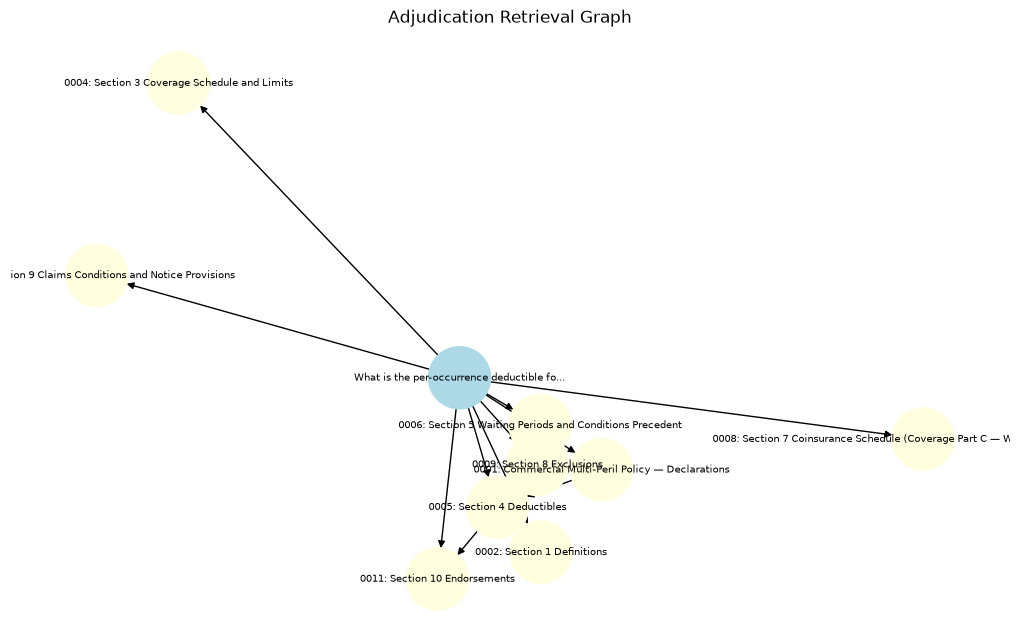

In [24]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    _q_label = result_a['question'][:40] + ('...' if len(result_a['question']) > 40 else '')
    G.add_node(_q_label, color='lightblue')
    _node_titles = {}
    for nid in result_a['selected_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)
        _label = f"{nid}: {_title}"
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    for ref in result_a.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color=_colors, node_size=2000, font_size=7, arrows=True)
    plt.title('Adjudication Retrieval Graph')
    plt.tight_layout()
    plt.show()
except Exception:
    print("\n(Visualization unavailable)")

---

## Scenario B: Benefit Tables & Rate Charts

### The Problem

Insurance policies contain structured tables — rate charts, benefit schedules, co-pay matrices — that are critical for accurate answers.

Standard chunking **shatters** tables:
- A table spanning one page might be split into 3-4 chunks.
- Headers get separated from their rows.
- Footnotes referencing table cells get lost.
- The LLM receives disconnected table fragments with no structural context.

Vectorless RAG retrieves **whole logical nodes**. PageIndex preserves table structure as a single node, so the LLM receives the complete table with headers, data, and footnotes intact.

### Ask a table-related question

Enter a question that requires reading a specific rate chart or benefit table.
The `answer_table_question()` function below runs the full pipeline as **one atomic step**:

1. **Targeted tree search** — The LLM identifies which node(s) contain the relevant table, reasoning about table headers and row labels in the tree. Because PageIndex preserves table structure, it can pinpoint the right schedule or rate chart.
2. **Table evidence extraction** — The full table node is retrieved as a whole logical node, preserving the complete structure: headers, rows, data, and footnotes. No chunking splits tables across fragments.
3. **Table-based answer** — The final LLM call reads the complete table and answers the specific rate or benefit question, returning exact numbers and a structured response.

Because all three steps run inside a single async function, re-running retrieval for a new question can never silently leave a stale answer from a previous run.

Run the cell below to ask a question, then run the following cells in order to see the full breakdown. If you ask a new question, re-run from this cell down.

In [25]:
TABLE_QUESTION = input(
    "Enter a table-related question (e.g., 'What is the coinsurance rate for out-of-network providers?'): "
).strip()
if not TABLE_QUESTION:
    raise ValueError("A question is required to continue.")

result_b = await answer_table_question(TABLE_QUESTION)

print("Question:", result_b["question"])

Question: What coinsurance rate applies to an out-of-network facility with no approved exception on file?


In [26]:
print(f"Selected {len(result_b['table_node_ids'])} node(s):", result_b["table_node_ids"])
print("\nRetrieval reasoning:")
print(result_b["retrieval_thinking"])
if result_b.get("cross_references"):
    print("\nCross-references:")
    for ref in result_b["cross_references"]:
        print(f"  {ref.get('from', '?')} -> {ref.get('to', '?')}: {ref.get('reason', '')}")

Selected 1 node(s): ['0008']

Retrieval reasoning:
The question asks for the coinsurance rate for an out-of-network facility with no approved exception on file. This information is likely found in a section related to coinsurance or coverage schedules. Section 7 Coinsurance Schedule (Coverage Part C — Warehouse Legal Liability) seems relevant as it discusses coinsurance rates for different types of facilities.

Cross-references:
  0008 -> 0009: Section 8 Exclusions may provide additional context or exceptions related to coinsurance rates for out-of-network facilities
  0008 -> 0010: Section 9 Claims Conditions and Notice Provisions may outline procedures for filing claims related to out-of-network facilities, which could be relevant to understanding coinsurance rates


In [27]:
print("\nTable evidence preview:\n")
print(preview_text(result_b["table_evidence"], limit=4000) if result_b["table_evidence"] else "(none)")
print("\nFinal answer:")
print(result_b["final_answer"])
print("\nTable reference:")
print(json.dumps(result_b["table_structure"], indent=2))
print("\nExplainability:")
print(json.dumps(result_b["explainability"], indent=2))


Table evidence preview:

[node=0008 page=4 title=Section 7 Coinsurance Schedule (Coverage Part C — Warehouse Legal Liability)]
## Section 7 Coinsurance Schedule (Coverage Part C — Warehouse Legal Liability)

Losses under Coverage Part C are subject to coinsurance based on whether the damaged customer goods were stored at a Meridian-approved (“in-network”) third-party cold-chain facility or a non-approved (“out-of-network”) facility at the time of loss.

|  Storage Facility Type | Coinsurance | Copay/Claim | Annual Max  |
| --- | --- | --- | --- |
|  In-Network Facility | 10% | $1,000 | $15,000  |
|  Out-of-Network (approved exception) | 25% | $2,500 | $40,000  |
|  Out-of-Network (no exception on file) | 50%* | $5,000 | No maximum  |

* The 50% coinsurance rate for unapproved out-of-network facilities is waived and reduced to 25% if the insured can demonstrate the facility met Meridian’s cold-chain standards at the time of loss, per underwriting bulletin UW-2025-14. This exception mus

In [28]:
if result_b["table_evidence"].strip():
    groundedness_system_prompt = """
You are a fact-checking assistant. You will be given an answer and the
evidence text it was supposed to be based on. Determine whether the
answer's claims are actually supported by the evidence.

Return valid JSON with this shape:
{
  "grounded": true or false,
  "reason": "one short sentence explaining your judgment"
}

Do not output markdown, prose, or extra keys.
""".strip()

    groundedness_user_prompt = f"""
Answer to check:
{result_b['final_answer']}

Evidence it should be based on:
{result_b['table_evidence']}
""".strip()

    try:
        groundedness_json = await call_llm_and_parse(groundedness_system_prompt, groundedness_user_prompt)
        if groundedness_json.get("grounded") is False:
            print("\n\u26a0\ufe0f  GROUNDEDNESS WARNING: This answer may not be fully supported by the retrieved evidence.")
            print(f"   Reason: {groundedness_json.get('reason', 'No reason given.')}")
        else:
            print("\n\u2705 Groundedness check passed: answer is supported by the retrieved evidence.")
    except Exception:
        print("\n(Groundedness check could not be completed.)")


✅ Groundedness check passed: answer is supported by the retrieved evidence.


C:\Users\risha\AppData\Local\Temp\ipykernel_17548\453710552.py:25: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


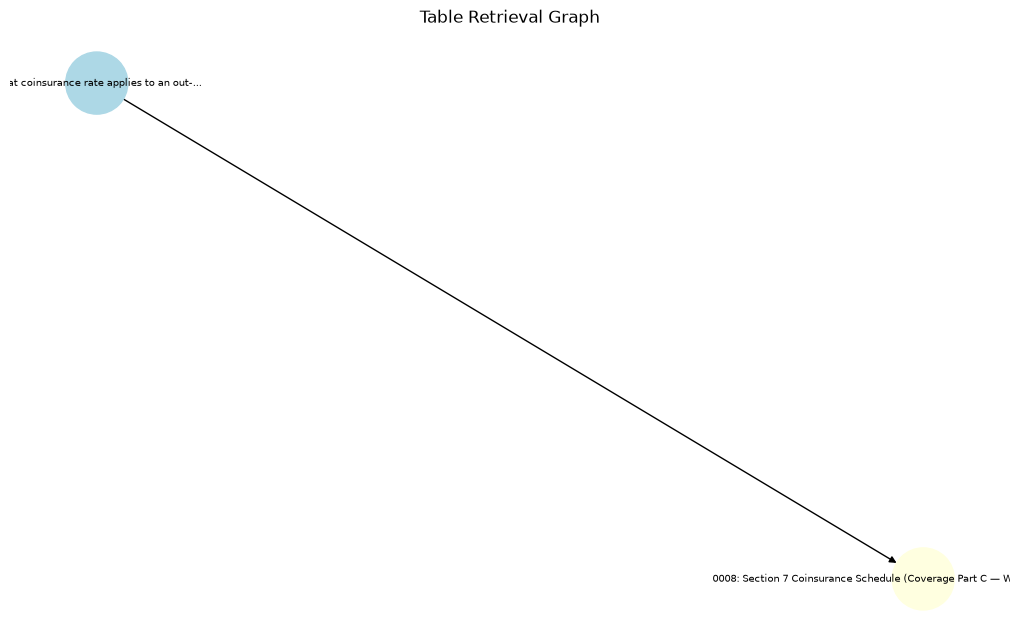

In [29]:
try:
    import networkx as nx
    import matplotlib.pyplot as plt
    G = nx.DiGraph()
    _q_label = result_b['question'][:40] + ('...' if len(result_b['question']) > 40 else '')
    G.add_node(_q_label, color='lightblue')
    _node_titles = {}
    for nid in result_b['table_node_ids']:
        _node = node_map.get(nid, {})
        _title = _node.get('title', nid)
        _label = f"{nid}: {_title}"
        _node_titles[nid] = _label
        G.add_node(_label, color='lightyellow')
        G.add_edge(_q_label, _label)
    for ref in result_b.get('cross_references', []):
        _src = _node_titles.get(ref.get('from', ''), ref.get('from', ''))
        _tgt = _node_titles.get(ref.get('to', ''), ref.get('to', ''))
        if _src in G.nodes and _tgt in G.nodes:
            G.add_edge(_src, _tgt)
    _colors = [G.nodes[n].get('color', 'white') for n in G.nodes]
    plt.figure(figsize=(10, 6))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color=_colors, node_size=2000, font_size=7, arrows=True)
    plt.title('Table Retrieval Graph')
    plt.tight_layout()
    plt.show()
except Exception:
    print("\n(Visualization unavailable)")